In [20]:
import uproot
import matplotlib.pyplot as plt
import pandas as pd
import tqdm
import numpy as np
import os
import glob
import awkward as ak
import boost_histogram as bh
import mplhep as mh
from matplotlib.colors import LogNorm
import math
mh.style.use("ATLAS")
# !pip install pyarrow
# !pip install "pyarrow<21" --break-system-packages

In [21]:
runs_F222 = [7733, 8712]
runs_F223 = [8713, 9188]

runs_F231 = [10555, 11470]
runs_F232 = [11470, 11703]

runs_F241 = [14399, 15026]
runs_tungsten = [15030, 15594]
runs_F242 = [15652, 15820]
runs_caloNu = [15821, 16924]
runs_F243 = [16928, 17230]

runs_2022 = [8025, 9188]
runs_2023 = [10604, 11703]

runs_2024_preCaloNu = [14399, 15821]
runs_2024_CaloNu = [15821, 16924]
runs_2024_afterCaloNu = [16928, 17230]

In [22]:
def parse_grl_csv(file_path):
    grl_df = pd.read_csv(file_path)
    return grl_df

grl_2022_df = parse_grl_csv("/cvmfs/faser.cern.ch/repo/sw/runlist/v10/faser_goodrunlist_2022_physics.csv")
grl_2023_df = parse_grl_csv("/cvmfs/faser.cern.ch/repo/sw/runlist/v10/faser_goodrunlist_2023_physics.csv")
grl_2024_df = parse_grl_csv("/cvmfs/faser.cern.ch/repo/sw/runlist/v10/faser_goodrunlist_2024_physics.csv")
grl_df = pd.concat([grl_2022_df, grl_2023_df, grl_2024_df], ignore_index=True)

In [23]:
data_files = glob.glob("AnalysisZipFramework/submission/analysis_output-moreHists4/*.root")

calonu_data_files = []
non_caloNu_2024_data_files = []

for file in data_files:
    run_num = int(os.path.basename(file).split('.')[0])

    if runs_caloNu[0] <= run_num <= runs_caloNu[1]:
        calonu_data_files.append(f"{file}")
    if runs_2024_preCaloNu[0] <= run_num <= runs_2024_preCaloNu[1]:
        non_caloNu_2024_data_files.append(f"{file}")
    if runs_2024_afterCaloNu[0] <= run_num <= runs_2024_afterCaloNu[1]:
        non_caloNu_2024_data_files.append(f"{file}")
    

In [24]:
def sum_histograms_in_files(files):

    hist_dict = {}
    for file in tqdm.tqdm(files, desc="Processing files"):
        with uproot.open(f"{file}:histograms") as f:
            for key in f.keys():
                if key not in hist_dict:
                    hist_dict[key] = f[key].to_boost()
                else:
                    hist_dict[key] += f[key].to_boost()

    return hist_dict

In [25]:
df_data_caloNu = uproot.concatenate([f"{f}:nt" for f in calonu_data_files], library="pd", filter_name=["VetoNu0_reduced_charge", "VetoNu1_reduced_charge", "CaloNu_total_E_EM"])
hists_data_caloNu = sum_histograms_in_files(calonu_data_files)

Processing files: 100%|██████████| 130/130 [00:20<00:00,  6.47it/s]


In [26]:
df_data_nocaloNu = uproot.concatenate([f"{f}:nt" for f in non_caloNu_2024_data_files], library="pd", filter_name=["VetoNu0_reduced_charge", "VetoNu1_reduced_charge", "CaloNu_total_E_EM"])
hists_data_nocaloNu = sum_histograms_in_files(non_caloNu_2024_data_files)

Processing files: 100%|██████████| 146/146 [00:22<00:00,  6.46it/s]


In [27]:
df_mc_CaloNu = uproot.concatenate("build/MC_no_truth_cuts_moreHists/2024_CaloNu.bck.root:nt", library="pd", filter_name=["VetoNu0_reduced_charge", "VetoNu1_reduced_charge", "CaloNu_total_E_EM", "truth_dec_z_nu"])
hists_mc_CaloNu = uproot.open("build/MC_no_truth_cuts_moreHists/2024_CaloNu.bck.root:histograms")

In [28]:
df_mc_noCaloNu = uproot.concatenate("build/MC_no_truth_cuts_moreHists/2024_noCaloNu.bck.root:nt", library="pd", filter_name=["VetoNu0_reduced_charge", "VetoNu1_reduced_charge", "CaloNu_total_E_EM", "truth_dec_z_nu"])
hists_mc_noCaloNu = uproot.open("build/MC_no_truth_cuts_moreHists/2024_noCaloNu.bck.root:histograms")

In [29]:
cut_val = 12.72e3
df_data_below = df_data_caloNu[df_data_caloNu["CaloNu_total_E_EM"] < cut_val]
df_data_above = df_data_caloNu[df_data_caloNu["CaloNu_total_E_EM"] >= cut_val]

df_mc_CaloNu_below = df_mc_CaloNu[df_mc_CaloNu["CaloNu_total_E_EM"] < cut_val]
df_mc_CaloNu_above = df_mc_CaloNu[df_mc_CaloNu["CaloNu_total_E_EM"] >= cut_val]

# front = [-2987.39, -2246.18]
front = [-4000, -2246.18]
# back = [-2246.18, -1946.18]
back = [-2246.18, -1000]

MC Front Region: 6082, MC Back Region: 18564, MC Total: 24648
MC Front Fraction: 24.68%, MC Back Fraction: 75.32%


<Axes: xlabel='VetoNu0 Reduced Charge [pC]', ylabel='$\\frac{Data}{MC}$'>

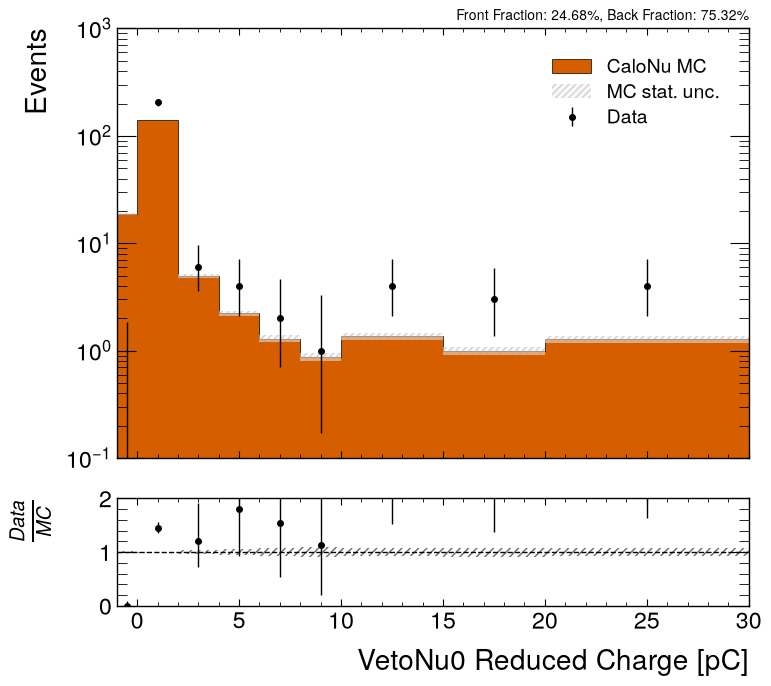

In [30]:
bins = [-1, 0, 2, 4, 6, 8, 10, 15, 20, 30]
h_data_reduced_charge0 = bh.Histogram(bh.axis.Variable(bins))
h_data_reduced_charge0.fill(df_data_caloNu["VetoNu0_reduced_charge"].to_numpy())

h_mc_reduced_charge0 = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Weight())
weight = 70.03 / 10_000  # Normalisation weight for MC
h_mc_reduced_charge0.fill(df_mc_CaloNu["VetoNu0_reduced_charge"].to_numpy(), weight=weight) # Normalise to lumi

n_mc_front = df_mc_CaloNu[(df_mc_CaloNu["truth_dec_z_nu"] >= front[0]) & (df_mc_CaloNu["truth_dec_z_nu"] < front[1])].shape[0]
n_mc_back = df_mc_CaloNu[(df_mc_CaloNu["truth_dec_z_nu"] >= back[0]) & (df_mc_CaloNu["truth_dec_z_nu"] < back[1])].shape[0]
n_mc_total = df_mc_CaloNu.shape[0]
print(f"MC Front Region: {n_mc_front}, MC Back Region: {n_mc_back}, MC Total: {n_mc_total}")
print(f"MC Front Fraction: {n_mc_front/n_mc_total:.2%}, MC Back Fraction: {n_mc_back/n_mc_total:.2%}")

# Create comparison plot
fig, ax_main, ax_comp = mh.comp.data_model(
 data_hist=h_data_reduced_charge0,
 stacked_components=[h_mc_reduced_charge0],
 stacked_labels=['CaloNu MC'],
 xlabel='VetoNu0 Reduced Charge [pC]',
 ylabel='Events',
 flow='hint'
)

ax_main.set_yscale('log')
ax_main.set_title(f"Front Fraction: {n_mc_front/n_mc_total:.2%}, Back Fraction: {n_mc_back/n_mc_total:.2%}", fontsize=10, loc="right")

mh.mpl_magic(soft_fail=True) # Autofit label


<Axes: xlabel='VetoNu0 Reduced Charge [pC]', ylabel='$\\frac{Data}{MC}$'>

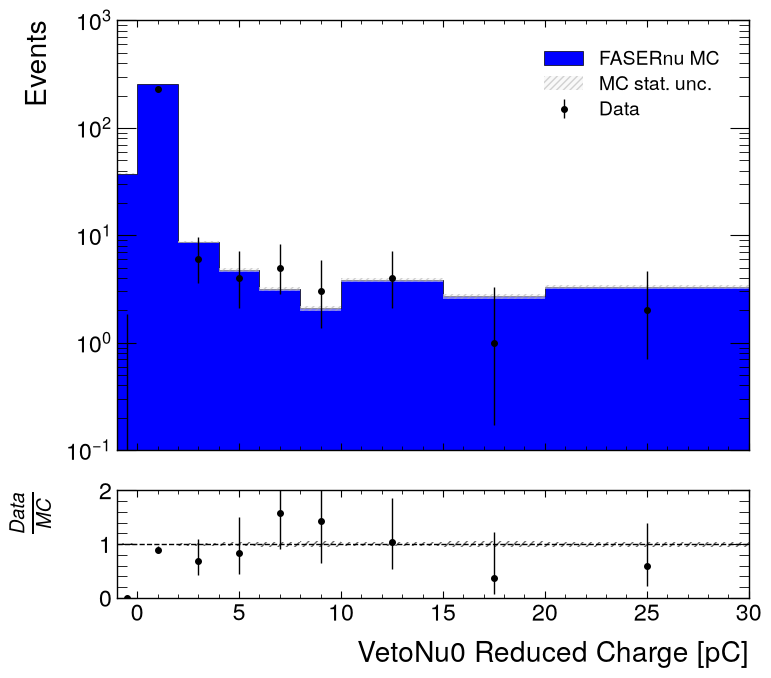

In [31]:
bins = [-1, 0, 2, 4, 6, 8, 10, 15, 20, 30]
h_data_reduced_charge0 = bh.Histogram(bh.axis.Variable(bins))
h_data_reduced_charge0.fill(df_data_nocaloNu["VetoNu0_reduced_charge"].to_numpy())

h_mc_reduced_charge0 = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Weight())
weight = 70.03 / 10_000  # Normalisation weight for MC
h_mc_reduced_charge0.fill(df_mc_noCaloNu["VetoNu0_reduced_charge"].to_numpy(), weight=weight) # Normalise to lumi

# Create comparison plot
fig, ax_main, ax_comp = mh.comp.data_model(
 data_hist=h_data_reduced_charge0,
 stacked_components=[h_mc_reduced_charge0],
 stacked_colors=['blue'],
 stacked_labels=['FASERnu MC'],
 xlabel='VetoNu0 Reduced Charge [pC]',
 ylabel='Events',
 flow='hint'
)

ax_main.set_yscale('log')

mh.mpl_magic(soft_fail=True) # Autofit label


MC Front Region: 2055, MC Back Region: 18563, MC Total: 20620
MC Front Fraction: 9.97%, MC Back Fraction: 90.02%


<Axes: xlabel='VetoNu0 Reduced Charge [pC]', ylabel='$\\frac{Data}{MC}$'>

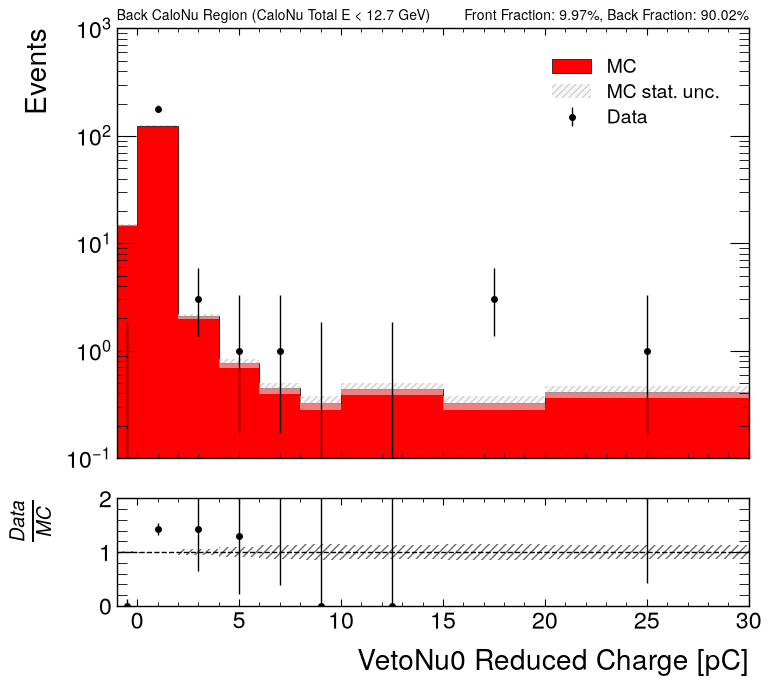

In [32]:
bins = [-1, 0, 2, 4, 6, 8, 10, 15, 20, 30]

h_data_reduced_charge0 = bh.Histogram(bh.axis.Variable(bins))
h_data_reduced_charge0.fill(df_data_below["VetoNu0_reduced_charge"].to_numpy())

h_mc_reduced_charge0 = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Weight())
weight = 70.03 / 10_000  # Normalisation weight for MC
h_mc_reduced_charge0.fill(df_mc_CaloNu_below["VetoNu0_reduced_charge"].to_numpy(), weight=weight) # Normalise to lumi

n_mc_front = df_mc_CaloNu_below[(df_mc_CaloNu_below["truth_dec_z_nu"] >= front[0]) & (df_mc_CaloNu_below["truth_dec_z_nu"] < front[1])].shape[0]
n_mc_back = df_mc_CaloNu_below[(df_mc_CaloNu_below["truth_dec_z_nu"] >= back[0]) & (df_mc_CaloNu_below["truth_dec_z_nu"] < back[1])].shape[0]
n_mc_total = df_mc_CaloNu_below.shape[0]
print(f"MC Front Region: {n_mc_front}, MC Back Region: {n_mc_back}, MC Total: {n_mc_total}")
print(f"MC Front Fraction: {n_mc_front/n_mc_total:.2%}, MC Back Fraction: {n_mc_back/n_mc_total:.2%}")


# Create comparison plot
fig, ax_main, ax_comp = mh.comp.data_model(
 data_hist=h_data_reduced_charge0,
 stacked_components=[h_mc_reduced_charge0],
 stacked_labels=['MC'],
 stacked_colors=["red"],
 xlabel='VetoNu0 Reduced Charge [pC]',
 ylabel='Events',
 flow='hint'
)

ax_main.set_yscale('log')
ax_main.set_title(f'Back CaloNu Region (CaloNu Total E < {cut_val/1000:.1f} GeV)', fontsize=10, loc="left")
ax_main.set_title(f"Front Fraction: {n_mc_front/n_mc_total:.2%}, Back Fraction: {n_mc_back/n_mc_total:.2%}", fontsize=10, loc="right")
mh.mpl_magic(soft_fail=True) # Autofit label


<Axes: xlabel='VetoNu1 Reduced Charge [pC]', ylabel='$\\frac{Data}{MC}$'>

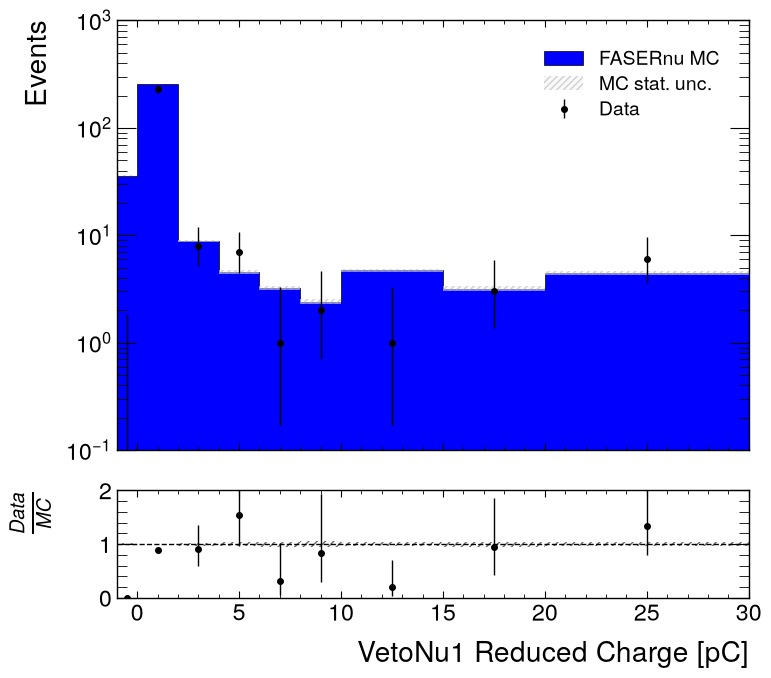

In [33]:
bins = [-1, 0, 2, 4, 6, 8, 10, 15, 20, 30]
h_data_reduced_charge0 = bh.Histogram(bh.axis.Variable(bins))
h_data_reduced_charge0.fill(df_data_nocaloNu["VetoNu1_reduced_charge"].to_numpy())

h_mc_reduced_charge0 = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Weight())
weight = 70.03 / 10_000  # Normalisation weight for MC
h_mc_reduced_charge0.fill(df_mc_noCaloNu["VetoNu1_reduced_charge"].to_numpy(), weight=weight) # Normalise to lumi

# Create comparison plot
fig, ax_main, ax_comp = mh.comp.data_model(
 data_hist=h_data_reduced_charge0,
 stacked_components=[h_mc_reduced_charge0],
 stacked_colors=['blue'],
 stacked_labels=['FASERnu MC'],
 xlabel='VetoNu1 Reduced Charge [pC]',
 ylabel='Events',
 flow='hint'
)

ax_main.set_yscale('log')

mh.mpl_magic(soft_fail=True) # Autofit label


MC Front Region: 4013, MC Back Region: 1, MC Total: 4014
MC Front Fraction: 99.98%, MC Back Fraction: 0.02%


<Axes: xlabel='VetoNu0 Reduced Charge [pC]', ylabel='$\\frac{Data}{MC}$'>

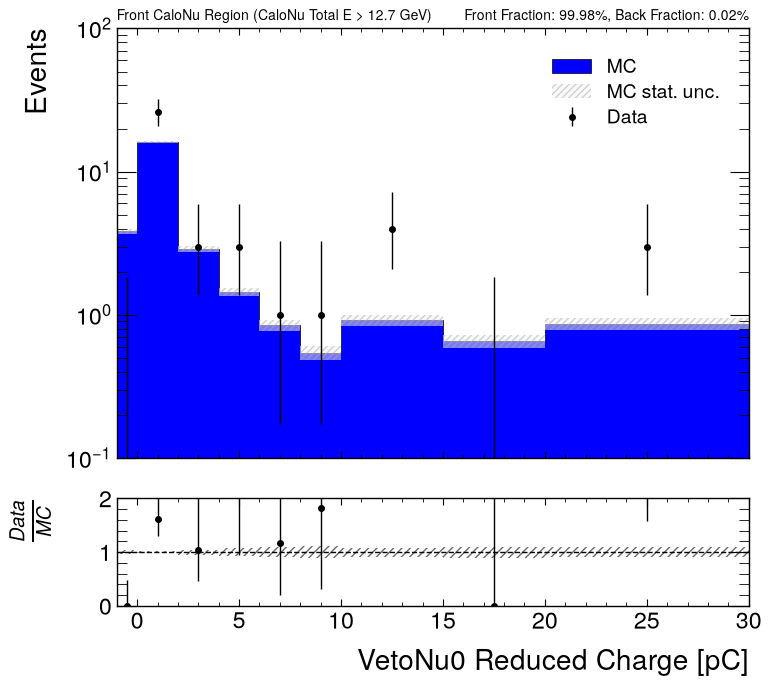

In [34]:
bins = [-1, 0, 2, 4, 6, 8, 10, 15, 20, 30]

h_data_reduced_charge0 = bh.Histogram(bh.axis.Variable(bins))
h_data_reduced_charge0.fill(df_data_above["VetoNu0_reduced_charge"].to_numpy())

h_mc_reduced_charge0 = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Weight())
weight = 70.03 / 10_000  # Normalisation weight for MC
h_mc_reduced_charge0.fill(df_mc_CaloNu_above["VetoNu0_reduced_charge"].to_numpy(), weight=weight) # Normalise to lumi

n_mc_front = df_mc_CaloNu_above[(df_mc_CaloNu_above["truth_dec_z_nu"] >= front[0]) & (df_mc_CaloNu_above["truth_dec_z_nu"] < front[1])].shape[0]
n_mc_back = df_mc_CaloNu_above[(df_mc_CaloNu_above["truth_dec_z_nu"] >= back[0]) & (df_mc_CaloNu_above["truth_dec_z_nu"] < back[1])].shape[0]
n_mc_total = df_mc_CaloNu_above.shape[0]
print(f"MC Front Region: {n_mc_front}, MC Back Region: {n_mc_back}, MC Total: {n_mc_total}")
print(f"MC Front Fraction: {n_mc_front/n_mc_total:.2%}, MC Back Fraction: {n_mc_back/n_mc_total:.2%}")



# Create comparison plot
fig, ax_main, ax_comp = mh.comp.data_model(
 data_hist=h_data_reduced_charge0,
 stacked_components=[h_mc_reduced_charge0],
 stacked_colors=["blue"],
 stacked_labels=['MC'],
 xlabel='VetoNu0 Reduced Charge [pC]',
 ylabel='Events',
 flow='hint'
)

ax_main.set_yscale('log')
ax_main.set_title(f'Front CaloNu Region (CaloNu Total E > {cut_val/1000:.1f} GeV)', fontsize=10, loc="left")
ax_main.set_title(f"Front Fraction: {n_mc_front/n_mc_total:.2%}, Back Fraction: {n_mc_back/n_mc_total:.2%}", fontsize=10, loc="right")
mh.mpl_magic(soft_fail=True) # Autofit label


MC Front Region: 6082, MC Back Region: 18564, MC Total: 24648
MC Front Fraction: 24.68%, MC Back Fraction: 75.32%


<Axes: xlabel='VetoNu1 Reduced Charge [pC]', ylabel='$\\frac{Data}{MC}$'>

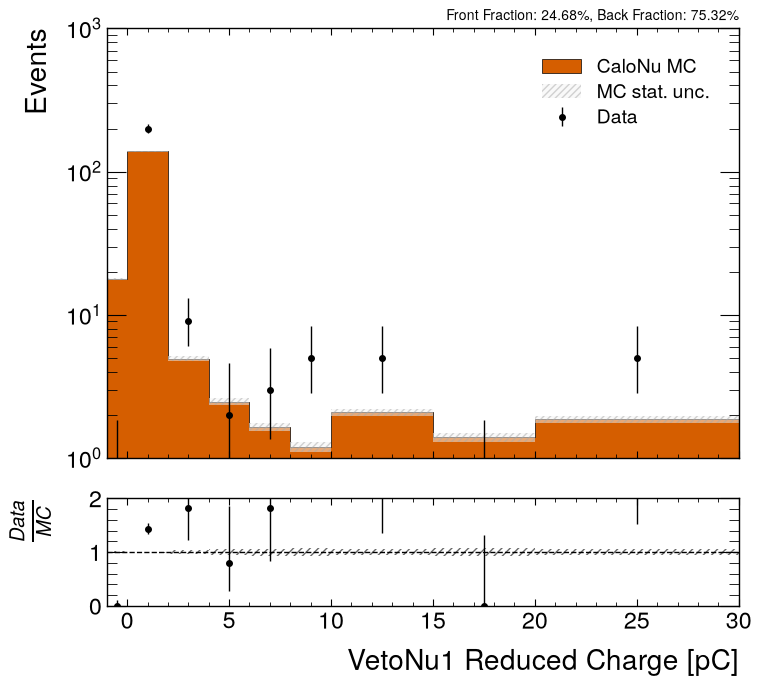

In [35]:
bins = [-1, 0, 2, 4, 6, 8, 10, 15, 20, 30]
h_data_reduced_charge0 = bh.Histogram(bh.axis.Variable(bins))
h_data_reduced_charge0.fill(df_data_caloNu["VetoNu1_reduced_charge"].to_numpy())

h_mc_reduced_charge0 = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Weight())
weight = 70.03 / 10_000  # Normalisation weight for MC
h_mc_reduced_charge0.fill(df_mc_CaloNu["VetoNu1_reduced_charge"].to_numpy(), weight=weight) # Normalise to lumi

n_mc_front = df_mc_CaloNu[(df_mc_CaloNu["truth_dec_z_nu"] >= front[0]) & (df_mc_CaloNu["truth_dec_z_nu"] < front[1])].shape[0]
n_mc_back = df_mc_CaloNu[(df_mc_CaloNu["truth_dec_z_nu"] >= back[0]) & (df_mc_CaloNu["truth_dec_z_nu"] < back[1])].shape[0]
n_mc_total = df_mc_CaloNu.shape[0]
print(f"MC Front Region: {n_mc_front}, MC Back Region: {n_mc_back}, MC Total: {n_mc_total}")
print(f"MC Front Fraction: {n_mc_front/n_mc_total:.2%}, MC Back Fraction: {n_mc_back/n_mc_total:.2%}")

# Create comparison plot
fig, ax_main, ax_comp = mh.comp.data_model(
 data_hist=h_data_reduced_charge0,
 stacked_components=[h_mc_reduced_charge0],
 stacked_labels=['CaloNu MC'],
 xlabel='VetoNu1 Reduced Charge [pC]',
 ylabel='Events',
 flow='hint'
)

ax_main.set_title(f"Front Fraction: {n_mc_front/n_mc_total:.2%}, Back Fraction: {n_mc_back/n_mc_total:.2%}", fontsize=10, loc="right")
ax_main.set_yscale('log')
mh.mpl_magic(soft_fail=True) # Autofit label


MC Front Region: 2055, MC Back Region: 18563, MC Total: 20620
MC Front Fraction: 9.97%, MC Back Fraction: 90.02%


<Axes: xlabel='VetoNu1 Reduced Charge [pC]', ylabel='$\\frac{Data}{MC}$'>

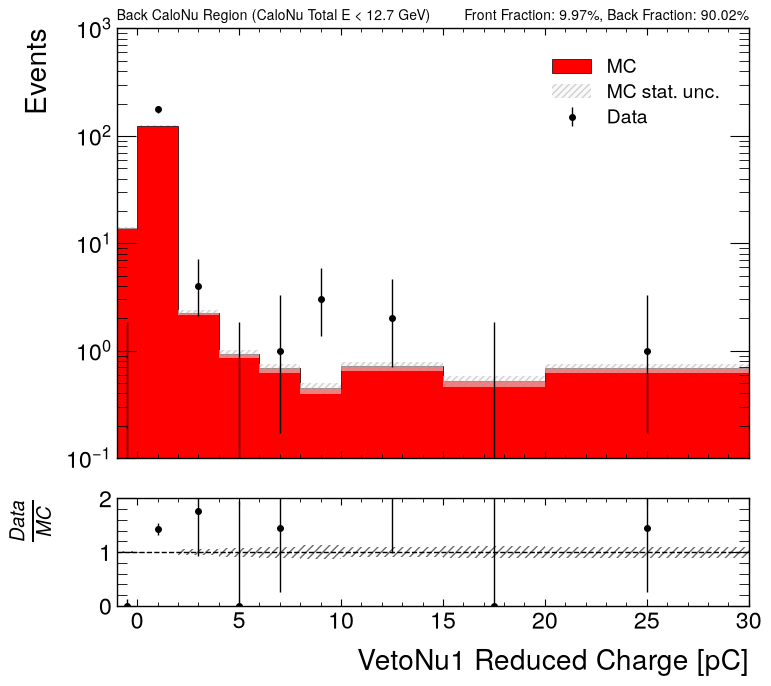

In [36]:
bins = [-1, 0, 2, 4, 6, 8, 10, 15, 20, 30]

h_data_reduced_charge0 = bh.Histogram(bh.axis.Variable(bins))
h_data_reduced_charge0.fill(df_data_below["VetoNu1_reduced_charge"].to_numpy())

h_mc_reduced_charge0 = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Weight())
weight = 70.03 / 10_000  # Normalisation weight for MC
h_mc_reduced_charge0.fill(df_mc_CaloNu_below["VetoNu1_reduced_charge"].to_numpy(), weight=weight) # Normalise to lumi

n_mc_front = df_mc_CaloNu_below[(df_mc_CaloNu_below["truth_dec_z_nu"] >= front[0]) & (df_mc_CaloNu_below["truth_dec_z_nu"] < front[1])].shape[0]
n_mc_back = df_mc_CaloNu_below[(df_mc_CaloNu_below["truth_dec_z_nu"] >= back[0]) & (df_mc_CaloNu_below["truth_dec_z_nu"] < back[1])].shape[0]
n_mc_total = df_mc_CaloNu_below.shape[0]
print(f"MC Front Region: {n_mc_front}, MC Back Region: {n_mc_back}, MC Total: {n_mc_total}")
print(f"MC Front Fraction: {n_mc_front/n_mc_total:.2%}, MC Back Fraction: {n_mc_back/n_mc_total:.2%}")


# Create comparison plot
fig, ax_main, ax_comp = mh.comp.data_model(
 data_hist=h_data_reduced_charge0,
 stacked_components=[h_mc_reduced_charge0],
 stacked_labels=['MC'],
 stacked_colors=["red"],
 xlabel='VetoNu1 Reduced Charge [pC]',
 ylabel='Events',
 flow='hint'
)

ax_main.set_yscale('log')
ax_main.set_title(f'Back CaloNu Region (CaloNu Total E < {cut_val/1000:.1f} GeV)', fontsize=10, loc="left")
ax_main.set_title(f"Front Fraction: {n_mc_front/n_mc_total:.2%}, Back Fraction: {n_mc_back/n_mc_total:.2%}", fontsize=10, loc="right")
mh.mpl_magic(soft_fail=True) # Autofit label


MC Front Region: 4013, MC Back Region: 1, MC Total: 4014
MC Front Fraction: 99.98%, MC Back Fraction: 0.02%


<Axes: xlabel='VetoNu1 Reduced Charge [pC]', ylabel='$\\frac{Data}{MC}$'>

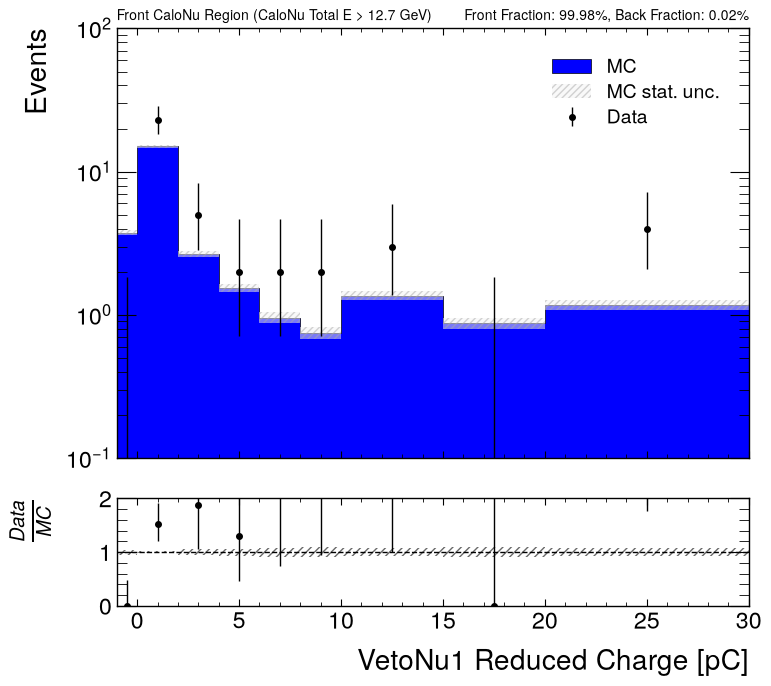

In [37]:
bins = [-1, 0, 2, 4, 6, 8, 10, 15, 20, 30]

h_data_reduced_charge0 = bh.Histogram(bh.axis.Variable(bins))
h_data_reduced_charge0.fill(df_data_above["VetoNu1_reduced_charge"].to_numpy())

h_mc_reduced_charge0 = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Weight())
weight = 70.03 / 10_000  # Normalisation weight for MC
h_mc_reduced_charge0.fill(df_mc_CaloNu_above["VetoNu1_reduced_charge"].to_numpy(), weight=weight) # Normalise to lumi

n_mc_front = df_mc_CaloNu_above[(df_mc_CaloNu_above["truth_dec_z_nu"] >= front[0]) & (df_mc_CaloNu_above["truth_dec_z_nu"] < front[1])].shape[0]
n_mc_back = df_mc_CaloNu_above[(df_mc_CaloNu_above["truth_dec_z_nu"] >= back[0]) & (df_mc_CaloNu_above["truth_dec_z_nu"] < back[1])].shape[0]
n_mc_total = df_mc_CaloNu_above.shape[0]
print(f"MC Front Region: {n_mc_front}, MC Back Region: {n_mc_back}, MC Total: {n_mc_total}")
print(f"MC Front Fraction: {n_mc_front/n_mc_total:.2%}, MC Back Fraction: {n_mc_back/n_mc_total:.2%}")


# Create comparison plot
fig, ax_main, ax_comp = mh.comp.data_model(
 data_hist=h_data_reduced_charge0,
 stacked_components=[h_mc_reduced_charge0],
 stacked_colors=["blue"],
 stacked_labels=['MC'],
 xlabel='VetoNu1 Reduced Charge [pC]',
 ylabel='Events',
 flow='hint'
)

ax_main.set_yscale('log')
ax_main.set_title(f'Front CaloNu Region (CaloNu Total E > {cut_val/1000:.1f} GeV)', fontsize=10, loc="left")
ax_main.set_title(f"Front Fraction: {n_mc_front/n_mc_total:.2%}, Back Fraction: {n_mc_back/n_mc_total:.2%}", fontsize=10, loc="right")
mh.mpl_magic(soft_fail=True) # Autofit label


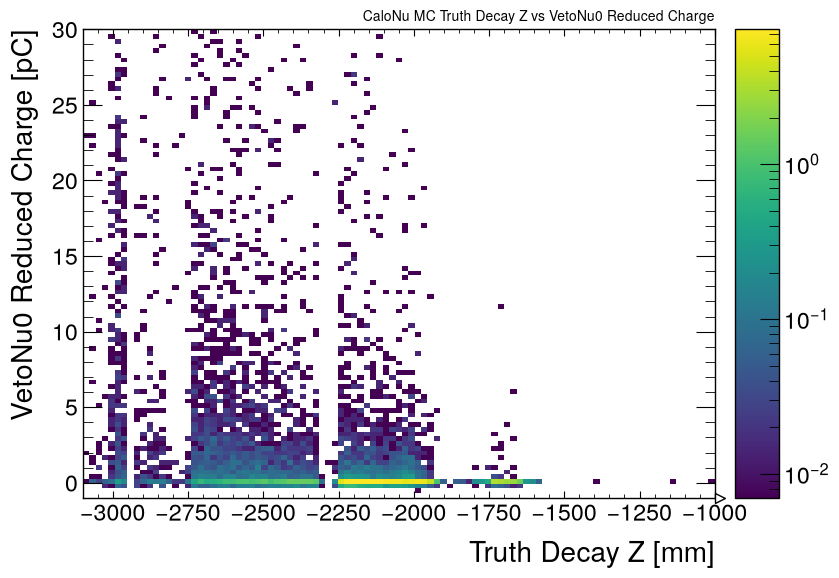

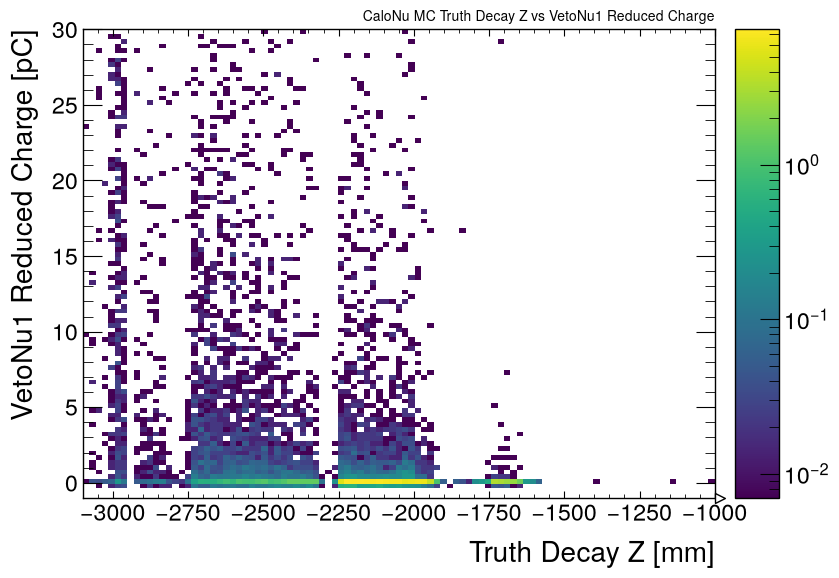

In [38]:
binsx = np.linspace(-3100, -1000, 100)
binsy = np.linspace(-1, 30, 100)

h_caloNu_mc_2d = bh.Histogram(bh.axis.Variable(binsx), bh.axis.Variable(binsy), storage=bh.storage.Weight())
weight = 70.03 / 10_000  # Normalisation weight for MC
h_caloNu_mc_2d.fill(df_mc_CaloNu["truth_dec_z_nu"].to_numpy(), df_mc_CaloNu["VetoNu0_reduced_charge"].to_numpy(), weight=weight) # Normalise to lumi

fig, ax = plt.subplots(figsize=(8, 6))
mh.hist2dplot(h_caloNu_mc_2d, ax=ax, cmap="viridis", norm=LogNorm())
ax.set_xlabel("Truth Decay Z [mm]")
ax.set_ylabel("VetoNu0 Reduced Charge [pC]")
ax.set_title("CaloNu MC Truth Decay Z vs VetoNu0 Reduced Charge", fontsize=10, loc="right");
plt.tight_layout()

binsx = np.linspace(-3100, -1000, 100)
binsy = np.linspace(-1, 30, 100)

h_caloNu_mc_2d = bh.Histogram(bh.axis.Variable(binsx), bh.axis.Variable(binsy), storage=bh.storage.Weight())
weight = 70.03 / 10_000  # Normalisation weight for MC
h_caloNu_mc_2d.fill(df_mc_CaloNu["truth_dec_z_nu"].to_numpy(), df_mc_CaloNu["VetoNu1_reduced_charge"].to_numpy(), weight=weight) # Normalise to lumi

fig, ax = plt.subplots(figsize=(8, 6))
mh.hist2dplot(h_caloNu_mc_2d, ax=ax, cmap="viridis", norm=LogNorm())
ax.set_xlabel("Truth Decay Z [mm]")
ax.set_ylabel("VetoNu1 Reduced Charge [pC]")
ax.set_title("CaloNu MC Truth Decay Z vs VetoNu1 Reduced Charge", fontsize=10, loc="right");
plt.tight_layout()

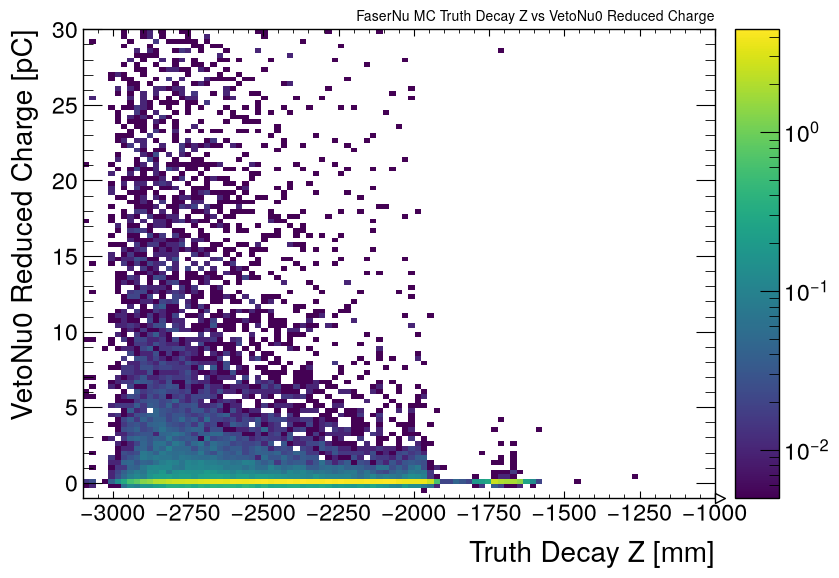

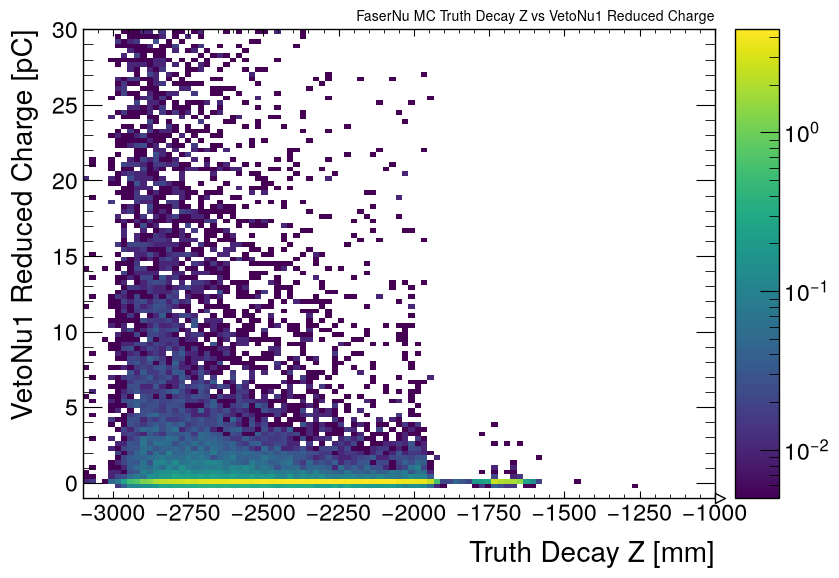

In [39]:
binsx = np.linspace(-3100, -1000, 100)
binsy = np.linspace(-1, 30, 100)

h_noCaloNu_mc_2d = bh.Histogram(bh.axis.Variable(binsx), bh.axis.Variable(binsy), storage=bh.storage.Weight())
weight = 50.01 / 10_000  # Normalisation weight for MC
h_noCaloNu_mc_2d.fill(df_mc_noCaloNu["truth_dec_z_nu"].to_numpy(), df_mc_noCaloNu["VetoNu0_reduced_charge"].to_numpy(), weight=weight) # Normalise to lumi

fig, ax = plt.subplots(figsize=(8, 6))
mh.hist2dplot(h_noCaloNu_mc_2d, ax=ax, cmap="viridis", norm=LogNorm())
ax.set_xlabel("Truth Decay Z [mm]")
ax.set_ylabel("VetoNu0 Reduced Charge [pC]")
ax.set_title("FaserNu MC Truth Decay Z vs VetoNu0 Reduced Charge", fontsize=10, loc="right");
plt.tight_layout()

binsx = np.linspace(-3100, -1000, 100)
binsy = np.linspace(-1, 30, 100)

h_noCaloNu_mc_2d = bh.Histogram(bh.axis.Variable(binsx), bh.axis.Variable(binsy), storage=bh.storage.Weight())
weight = 50.01 / 10_000  # Normalisation weight for MC
h_noCaloNu_mc_2d.fill(df_mc_noCaloNu["truth_dec_z_nu"].to_numpy(), df_mc_noCaloNu["VetoNu1_reduced_charge"].to_numpy(), weight=weight) # Normalise to lumi

fig, ax = plt.subplots(figsize=(8, 6))
mh.hist2dplot(h_noCaloNu_mc_2d, ax=ax, cmap="viridis", norm=LogNorm())
ax.set_xlabel("Truth Decay Z [mm]")
ax.set_ylabel("VetoNu1 Reduced Charge [pC]")
ax.set_title("FaserNu MC Truth Decay Z vs VetoNu1 Reduced Charge", fontsize=10, loc="right");
plt.tight_layout()

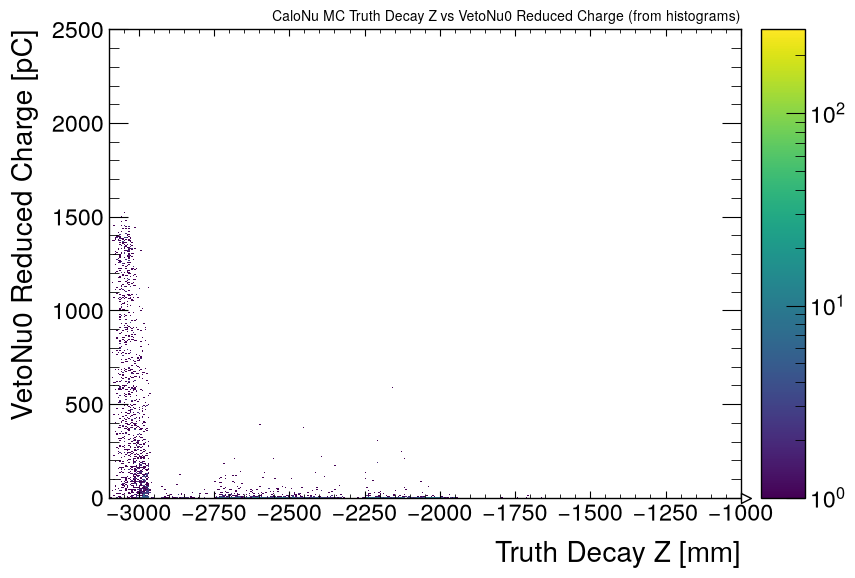

In [40]:
h_z_vs_q = hists_mc_CaloNu["truth_dec_z_nu_vs_VetoNu0_reduced_charge"]

fig, ax = plt.subplots(figsize=(8, 6))
mh.hist2dplot(h_z_vs_q, ax=ax, cmap="viridis", norm=LogNorm())
ax.set_xlabel("Truth Decay Z [mm]")
ax.set_ylabel("VetoNu0 Reduced Charge [pC]")
ax.set_title("CaloNu MC Truth Decay Z vs VetoNu0 Reduced Charge (from histograms)", fontsize=10, loc="right");
ax.set_xlim(-3100, -1000)
plt.tight_layout()

In [41]:
def scale_histogram(h, scale):
    h_weighted = bh.Histogram(*h.axes, storage=bh.storage.Weight())
    h_weighted.view().value[...] = h.values()
    h_weighted.view().variance[...] = h.values()  # Poisson: var = N
    h_weighted *= scale

    return h_weighted

<Axes: xlabel='VetoNu0 Reduced Charge [pC]', ylabel='$\\frac{Data}{MC}$'>

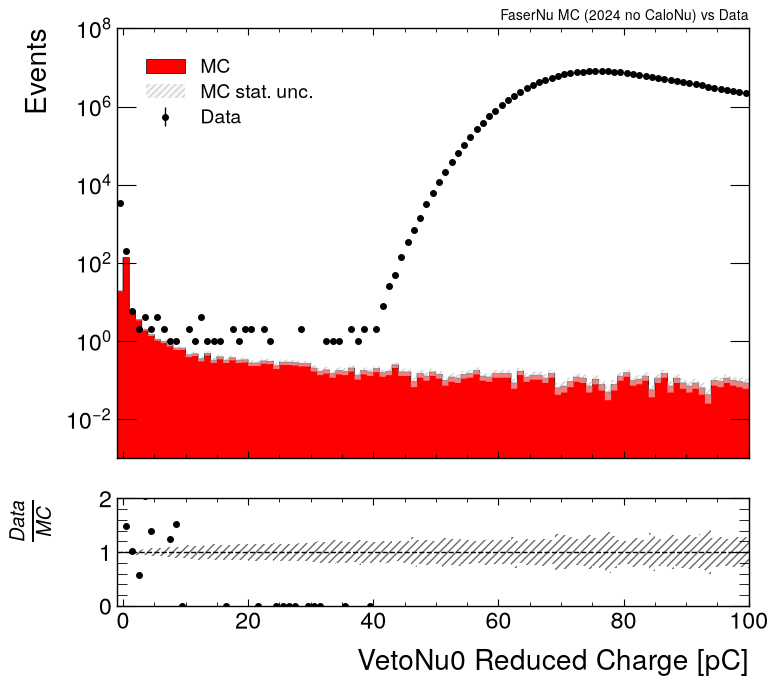

In [42]:
h_data_q = hists_data_caloNu["VetoNu0_reduced_charge;1"]
h_mc_q = hists_mc_CaloNu["VetoNu0_reduced_charge;1"].to_boost()

h_mc_q = scale_histogram(h_mc_q, 70.03 / 10_000)  # Normalisation weight for MC


fig, ax_main, ax_comp = mh.comp.data_model(
 data_hist=h_data_q,
 stacked_components=[h_mc_q],
 stacked_labels=['MC'],
 stacked_colors=["red"],
 xlabel='VetoNu0 Reduced Charge [pC]',
 ylabel='Events',
 flow='hint'
)

ax_main.set_yscale('log')
ax_main.set_xlim(-1, 100)
ax_comp.set_xlim(-1, 100)

ax_main.set_title(f"FaserNu MC (2024 no CaloNu) vs Data", fontsize=10, loc="right")
mh.mpl_magic(soft_fail=True) # Autofit label


<Axes: xlabel='VetoNu1 Reduced Charge [pC]', ylabel='$\\frac{Data}{MC}$'>

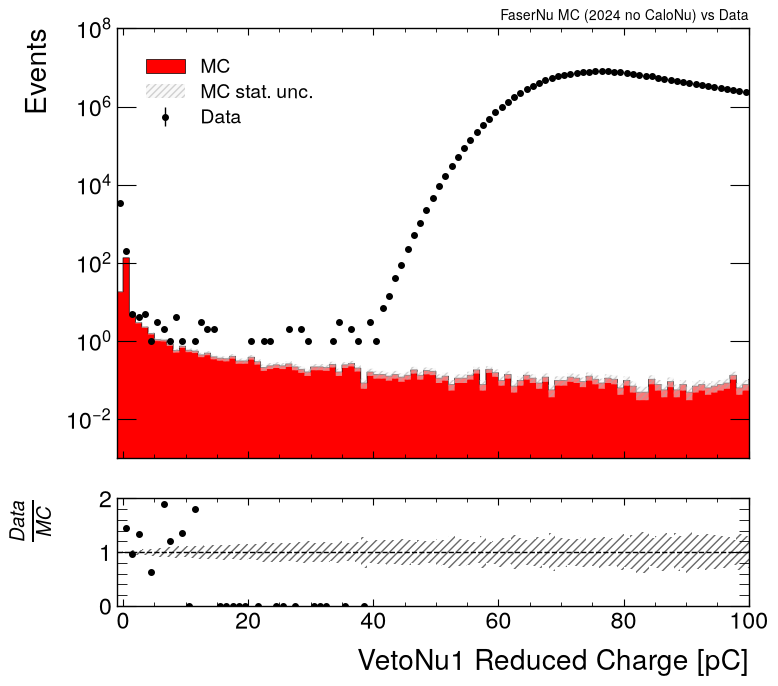

In [43]:
h_data_q = hists_data_caloNu["VetoNu1_reduced_charge;1"]
h_mc_q = hists_mc_CaloNu["VetoNu1_reduced_charge;1"].to_boost()

h_mc_q = scale_histogram(h_mc_q, 70.03 / 10_000)  # Normalisation weight for MC


fig, ax_main, ax_comp = mh.comp.data_model(
 data_hist=h_data_q,
 stacked_components=[h_mc_q],
 stacked_labels=['MC'],
 stacked_colors=["red"],
 xlabel='VetoNu1 Reduced Charge [pC]',
 ylabel='Events',
 flow='hint'
)

ax_main.set_yscale('log')
ax_main.set_xlim(-1, 100)
ax_comp.set_xlim(-1, 100)

ax_main.set_title(f"FaserNu MC (2024 no CaloNu) vs Data", fontsize=10, loc="right")
mh.mpl_magic(soft_fail=True) # Autofit label


<Axes: xlabel='VetoNu0 Reduced Charge [pC]', ylabel='$\\frac{Data}{MC}$'>

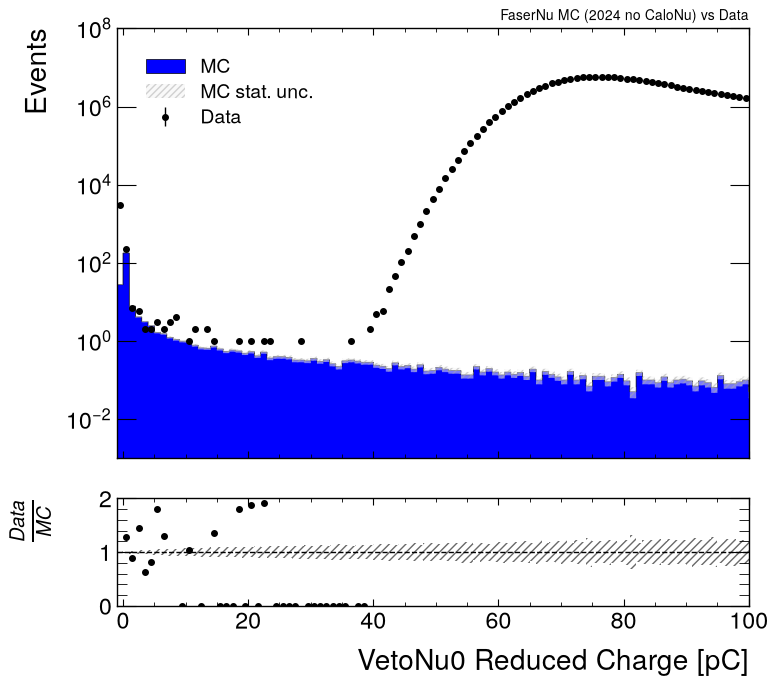

In [44]:
h_data_q = hists_data_nocaloNu["VetoNu0_reduced_charge;1"]
h_mc_q = hists_mc_noCaloNu["VetoNu0_reduced_charge;1"].to_boost()

h_mc_q = scale_histogram(h_mc_q, 50.1 / 10_000)  # Normalisation weight for MC
   

fig, ax_main, ax_comp = mh.comp.data_model(
 data_hist=h_data_q,
 stacked_components=[h_mc_q],
 stacked_labels=['MC'],
 stacked_colors=["blue"],
 xlabel='VetoNu0 Reduced Charge [pC]',
 ylabel='Events',
 flow='hint'
)

ax_main.set_yscale('log')
ax_main.set_xlim(-1, 100)
ax_comp.set_xlim(-1, 100)

ax_main.set_title(f"FaserNu MC (2024 no CaloNu) vs Data", fontsize=10, loc="right")
mh.mpl_magic(soft_fail=True) # Autofit label


<Axes: xlabel='VetoNu1 Reduced Charge [pC]', ylabel='$\\frac{Data}{MC}$'>

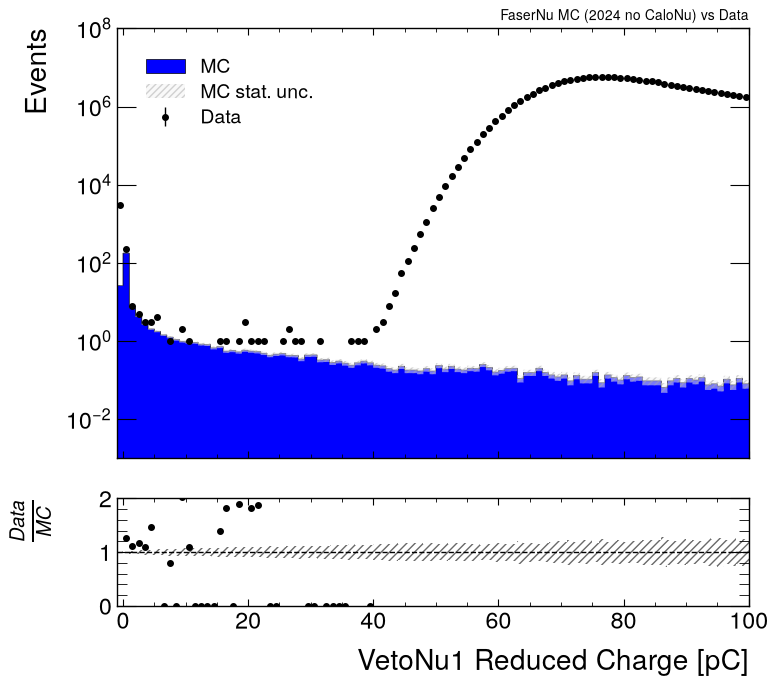

In [45]:
h_data_q = hists_data_nocaloNu["VetoNu1_reduced_charge;1"]
h_mc_q = hists_mc_noCaloNu["VetoNu1_reduced_charge;1"].to_boost()

h_mc_q = scale_histogram(h_mc_q, 50.1 / 10_000)  # Normalisation weight for MC
   

fig, ax_main, ax_comp = mh.comp.data_model(
 data_hist=h_data_q,
 stacked_components=[h_mc_q],
 stacked_labels=['MC'],
 stacked_colors=["blue"],
 xlabel='VetoNu1 Reduced Charge [pC]',
 ylabel='Events',
 flow='hint'
)

ax_main.set_yscale('log')
ax_main.set_xlim(-1, 100)
ax_comp.set_xlim(-1, 100)

ax_main.set_title(f"FaserNu MC (2024 no CaloNu) vs Data", fontsize=10, loc="right")
mh.mpl_magic(soft_fail=True) # Autofit label


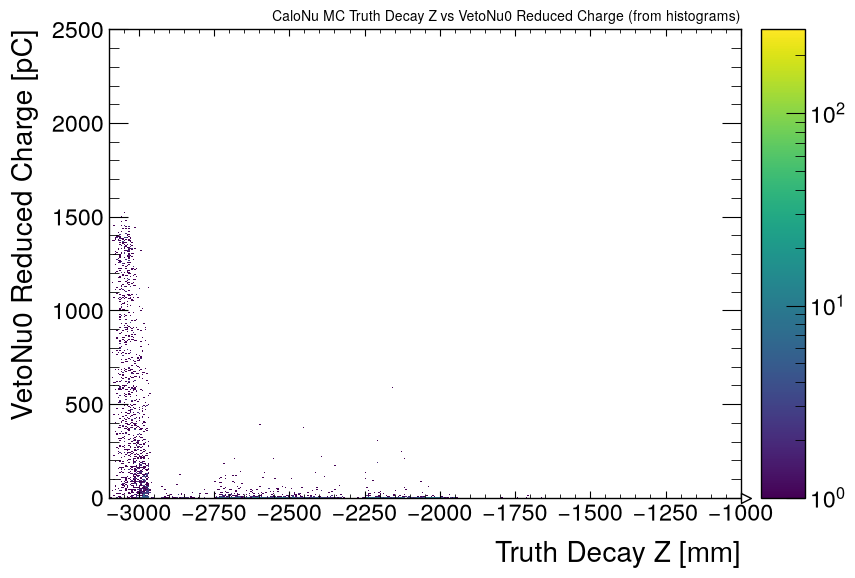

In [46]:
h_z_vs_q = hists_mc_CaloNu["truth_dec_z_nu_vs_VetoNu0_reduced_charge"]

fig, ax = plt.subplots(figsize=(8, 6))
mh.hist2dplot(h_z_vs_q, ax=ax, cmap="viridis", norm=LogNorm())
ax.set_xlabel("Truth Decay Z [mm]")
ax.set_ylabel("VetoNu0 Reduced Charge [pC]")
ax.set_title("CaloNu MC Truth Decay Z vs VetoNu0 Reduced Charge (from histograms)", fontsize=10, loc="right");
ax.set_xlim(-3100, -1000)
plt.tight_layout()

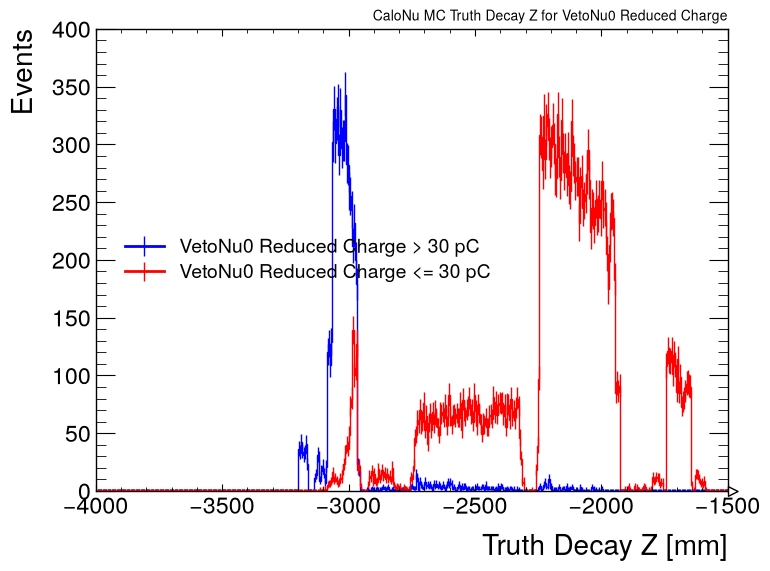

In [47]:
h_z_vs_q = hists_mc_CaloNu["truth_dec_z_nu_vs_VetoNu0_reduced_charge"].to_boost()
h_z_high_q_slice = h_z_vs_q[:, bh.loc(30):]
# The slice folded charge>=30 entries into the overflow bin of axis 1.
# Zero it out so project() doesn't bring them back in.
view = h_z_high_q_slice.view(flow=True)
view[:, -1] = 0   # zero overflow bin of axis 1 (charge)
view[:, 0] = 0   # also zero underflow if relevant to your cut
h_z_high_q_slice_projz = h_z_high_q_slice.project(0)

h_z_vs_q = hists_mc_CaloNu["truth_dec_z_nu_vs_VetoNu0_reduced_charge"].to_boost()
h_z_low_q_slice = h_z_vs_q[:, :bh.loc(30)]
# The slice folded charge>=30 entries into the overflow bin of axis 1.
# Zero it out so project() doesn't bring them back in.
view = h_z_low_q_slice.view(flow=True)
view[:, -1] = 0   # zero overflow bin of axis 1 (charge)
view[:, 0] = 0   # also zero underflow if relevant to your cut
h_z_low_q_slice_projz = h_z_low_q_slice.project(0)

fig, ax = plt.subplots(figsize=(8, 6))
mh.histplot(h_z_high_q_slice_projz, ax=ax, color="blue", label="VetoNu0 Reduced Charge > 30 pC")
mh.histplot(h_z_low_q_slice_projz, ax=ax, color="red", label="VetoNu0 Reduced Charge <= 30 pC")
ax.set_xlabel("Truth Decay Z [mm]")
ax.set_ylabel("Events")
ax.set_title("CaloNu MC Truth Decay Z for VetoNu0 Reduced Charge", fontsize=10, loc="right")
ax.legend()

Text(0, 1, '$\\frac{\\text{Charge} > \\text{30 pC}}{\\text{Charge} \\leq \\text{30 pC}}$')

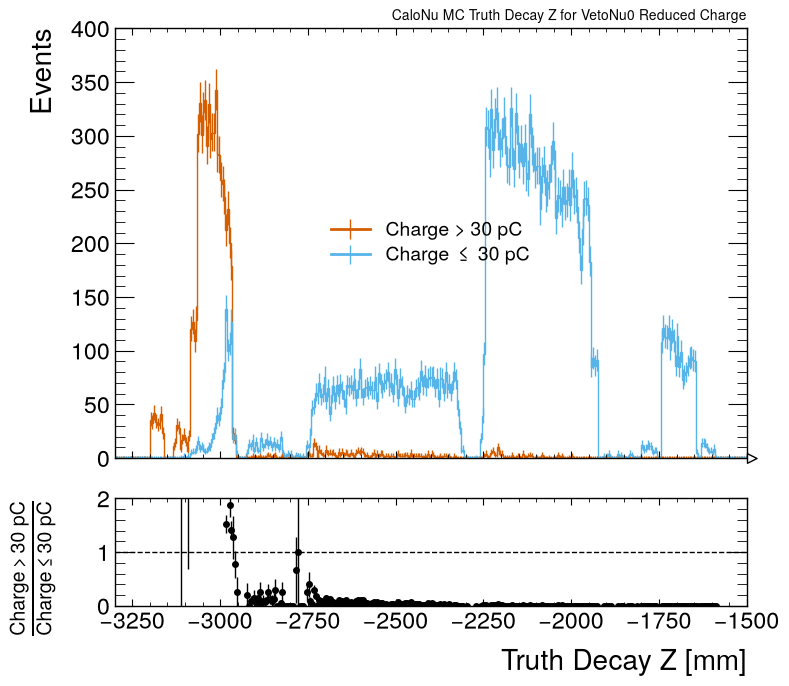

In [48]:
fig, ax_main, ax_comp = mh.comp.hists(
 h_z_high_q_slice_projz,
 h_z_low_q_slice_projz,
 comparison='ratio',
 xlabel='Truth Decay Z [mm]',
 ylabel='Events',
 h1_label='Charge > 30 pC',
 h2_label=r'Charge $\leq$ 30 pC'
)

ax_main.set_title("CaloNu MC Truth Decay Z for VetoNu0 Reduced Charge", fontsize=10, loc="right")
ax_main.set_xlim(-3300, -1500)
ax_comp.set_xlim(-3300, -1500)

ax_comp.set_ylabel(r"$\frac{\text{Charge} > \text{30 pC}}{\text{Charge} \leq \text{30 pC}}$")

Efficiency of VetoNu0 Reduced Charge < 30 pC: 78.58%
Inefficiency of VetoNu0 Reduced Charge > 30 pC: 21.40%


Text(1.0, 1.0, 'CaloNu MC Efficiency of VetoNu0 Reduced Charge > 30 pC vs Truth Decay Z')

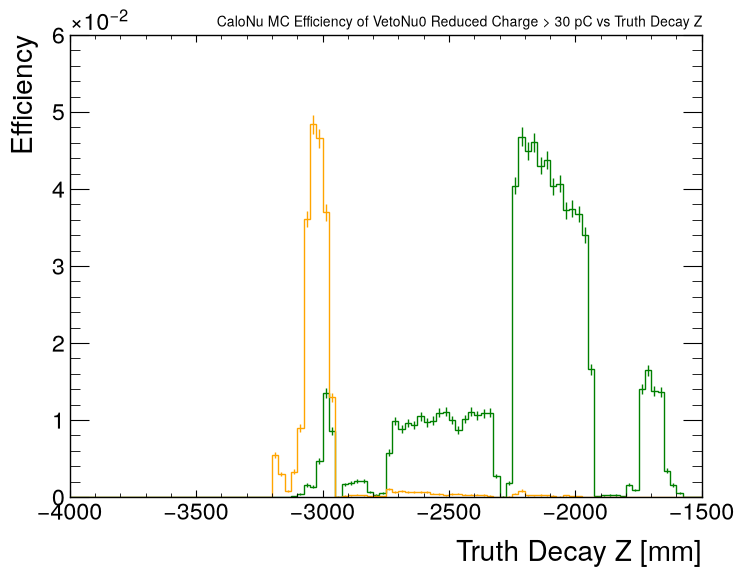

In [49]:
h_q_cut_eff_z = scale_histogram(h_z_low_q_slice_projz, 1/h_z_vs_q.sum(flow=True))

h_q_cut_ineff_z = scale_histogram(h_z_high_q_slice_projz, 1/h_z_vs_q.sum(flow=True))

print(f"Efficiency of VetoNu0 Reduced Charge < 30 pC: {h_q_cut_eff_z.sum(flow=True).value:.2%}")
print(f"Inefficiency of VetoNu0 Reduced Charge > 30 pC: {h_q_cut_ineff_z.sum(flow=True).value:.2%}")

fig, ax = plt.subplots(figsize=(8, 6))

rebin = 5

mh.histplot(h_q_cut_eff_z[bh.rebin(rebin)], ax=ax, color="green", label="Efficiency of VetoNu0 Reduced Charge < 30 pC")
mh.histplot(h_q_cut_ineff_z[bh.rebin(rebin)], ax=ax, color="orange", label="Inefficiency of VetoNu0 Reduced Charge > 30 pC")
ax.set_xlabel("Truth Decay Z [mm]")
ax.set_ylabel("Efficiency")
ax.set_title("CaloNu MC Efficiency of VetoNu0 Reduced Charge > 30 pC vs Truth Decay Z", fontsize=10, loc="right")

Efficiency of VetoNu0 Reduced Charge < 30 pC: nan%
Inefficiency of VetoNu0 Reduced Charge > 30 pC: nan%


(-3300.0, -1500.0)

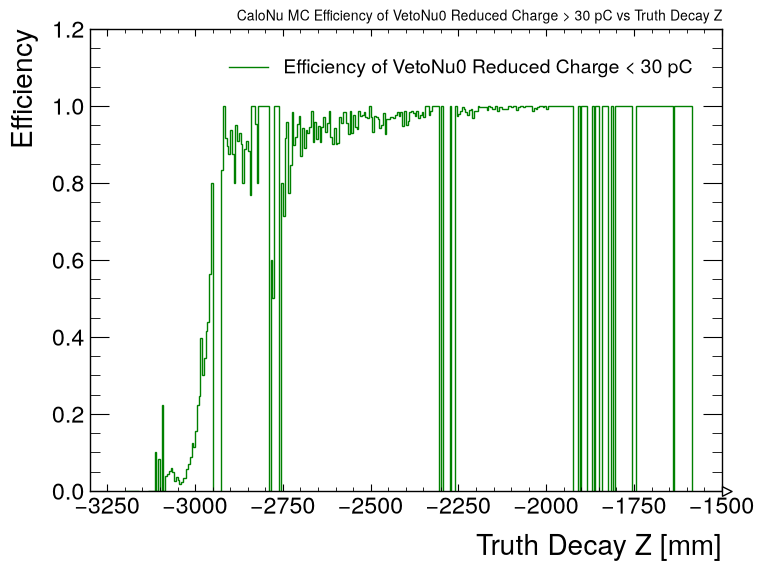

In [50]:
h_q_cut_eff_z = h_z_low_q_slice_projz / h_z_vs_q.project(0)

h_q_cut_ineff_z = h_z_high_q_slice_projz / h_z_vs_q.project(0)

print(f"Efficiency of VetoNu0 Reduced Charge < 30 pC: {h_q_cut_eff_z.sum(flow=True):.2%}")
print(f"Inefficiency of VetoNu0 Reduced Charge > 30 pC: {h_q_cut_ineff_z.sum(flow=True):.2%}")

fig, ax = plt.subplots(figsize=(8, 6))

rebin = 1

h_q_cut_eff_z_CaloNu = h_q_cut_eff_z[bh.rebin(rebin)]

mh.histplot(h_q_cut_eff_z[bh.rebin(rebin)], ax=ax, color="green", label="Efficiency of VetoNu0 Reduced Charge < 30 pC")
# mh.histplot(h_q_cut_ineff_z[bh.rebin(rebin)], ax=ax, color="orange", label="Inefficiency of VetoNu0 Reduced Charge > 30 pC")
ax.set_xlabel("Truth Decay Z [mm]")
ax.set_ylabel("Efficiency")
# ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.legend()
ax.set_title("CaloNu MC Efficiency of VetoNu0 Reduced Charge > 30 pC vs Truth Decay Z", fontsize=10, loc="right")
ax.set_xlim(-3300, -1500)

Efficiency of VetoNu1 Reduced Charge < 30 pC: 77.09%
Inefficiency of VetoNu1 Reduced Charge > 30 pC: 22.90%
Efficiency of VetoNu0 Reduced Charge < 30 pC: nan%
Inefficiency of VetoNu0 Reduced Charge > 30 pC: nan%


(-3300.0, -1500.0)

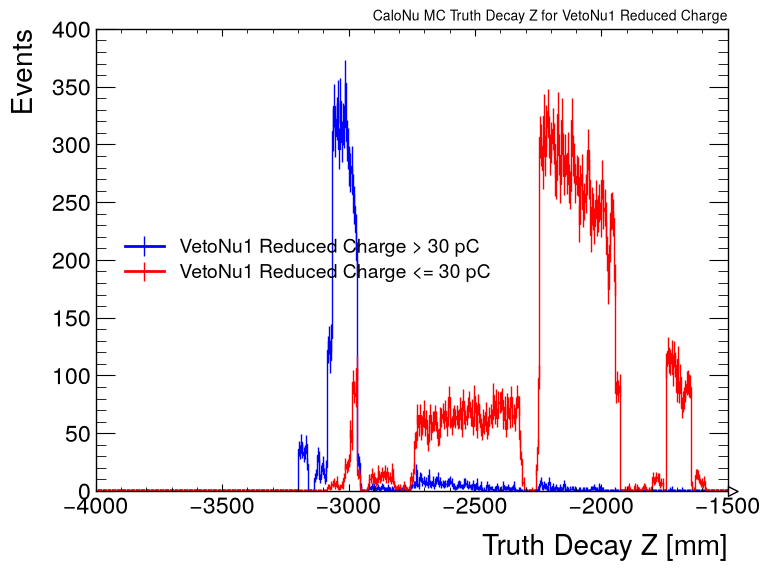

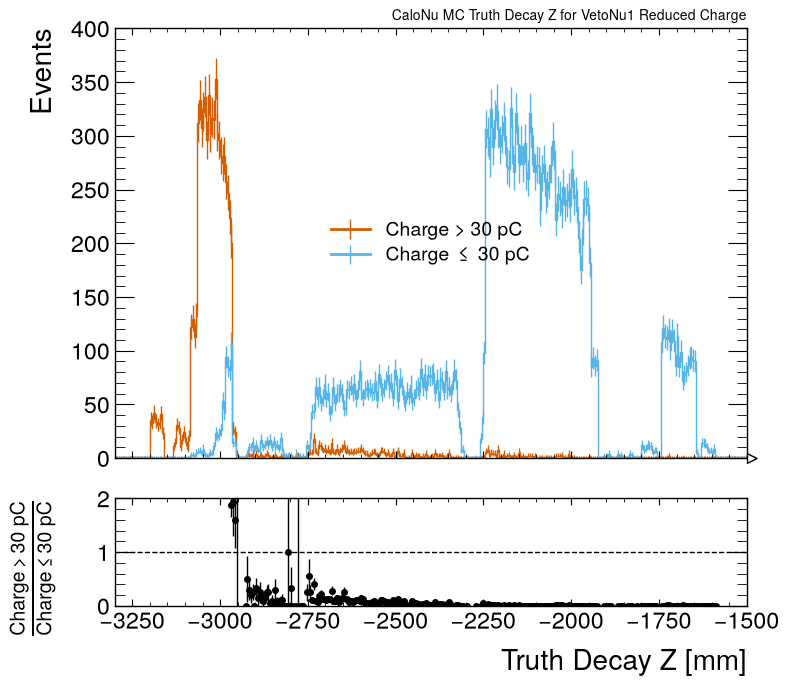

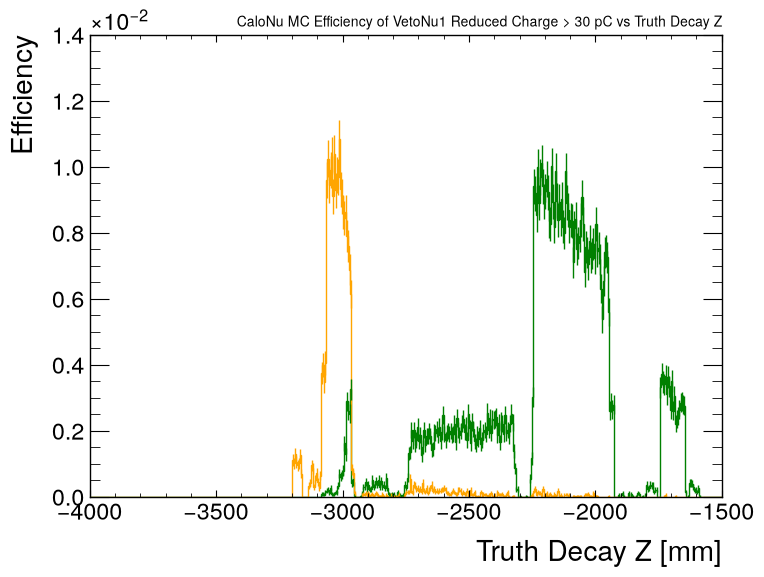

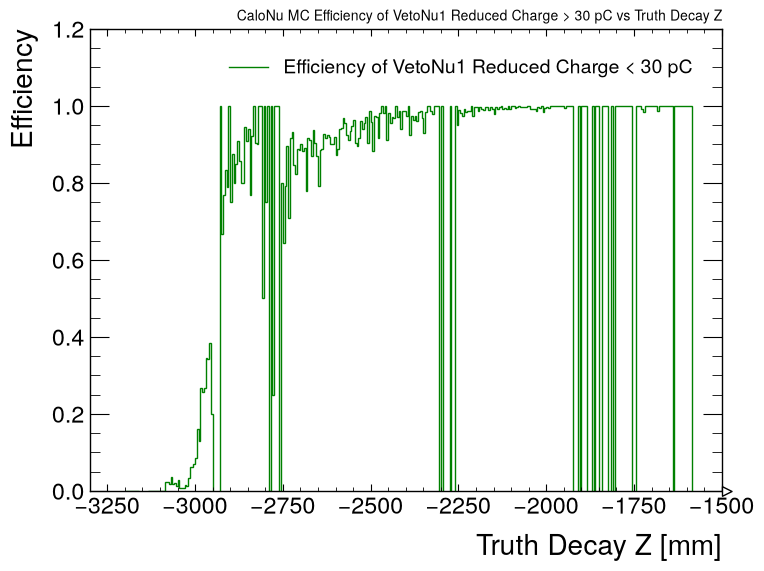

In [51]:
h_z_vs_q = hists_mc_CaloNu["truth_dec_z_nu_vs_VetoNu1_reduced_charge"].to_boost()
h_z_high_q_slice = h_z_vs_q[:, bh.loc(30):]
# The slice folded charge>=30 entries into the overflow bin of axis 1.
# Zero it out so project() doesn't bring them back in.
view = h_z_high_q_slice.view(flow=True)
view[:, -1] = 0   # zero overflow bin of axis 1 (charge)
view[:, 0] = 0   # also zero underflow if relevant to your cut
h_z_high_q_slice_projz = h_z_high_q_slice.project(0)

h_z_vs_q = hists_mc_CaloNu["truth_dec_z_nu_vs_VetoNu1_reduced_charge"].to_boost()
h_z_low_q_slice = h_z_vs_q[:, :bh.loc(30)]
# The slice folded charge>=30 entries into the overflow bin of axis 1.
# Zero it out so project() doesn't bring them back in.
view = h_z_low_q_slice.view(flow=True)
view[:, -1] = 0   # zero overflow bin of axis 1 (charge)
view[:, 0] = 0   # also zero underflow if relevant to your cut
h_z_low_q_slice_projz = h_z_low_q_slice.project(0)

fig, ax = plt.subplots(figsize=(8, 6))
mh.histplot(h_z_high_q_slice_projz, ax=ax, color="blue", label="VetoNu1 Reduced Charge > 30 pC")
mh.histplot(h_z_low_q_slice_projz, ax=ax, color="red", label="VetoNu1 Reduced Charge <= 30 pC")
ax.set_xlabel("Truth Decay Z [mm]")
ax.set_ylabel("Events")
ax.set_title("CaloNu MC Truth Decay Z for VetoNu1 Reduced Charge", fontsize=10, loc="right")
ax.legend()

fig, ax_main, ax_comp = mh.comp.hists(
 h_z_high_q_slice_projz,
 h_z_low_q_slice_projz,
 comparison='ratio',
 xlabel='Truth Decay Z [mm]',
 ylabel='Events',
 h1_label='Charge > 30 pC',
 h2_label=r'Charge $\leq$ 30 pC'
)

ax_main.set_title("CaloNu MC Truth Decay Z for VetoNu1 Reduced Charge", fontsize=10, loc="right")
ax_main.set_xlim(-3300, -1500)
ax_comp.set_xlim(-3300, -1500)

ax_comp.set_ylabel(r"$\frac{\text{Charge} > \text{30 pC}}{\text{Charge} \leq \text{30 pC}}$")

h_q_cut_eff_z = scale_histogram(h_z_low_q_slice_projz, 1/h_z_vs_q.sum(flow=True))

h_q_cut_ineff_z = scale_histogram(h_z_high_q_slice_projz, 1/h_z_vs_q.sum(flow=True))

print(f"Efficiency of VetoNu1 Reduced Charge < 30 pC: {h_q_cut_eff_z.sum(flow=True).value:.2%}")
print(f"Inefficiency of VetoNu1 Reduced Charge > 30 pC: {h_q_cut_ineff_z.sum(flow=True).value:.2%}")

fig, ax = plt.subplots(figsize=(8, 6))
mh.histplot(h_q_cut_eff_z, ax=ax, color="green", label="Efficiency of VetoNu1 Reduced Charge < 30 pC")
mh.histplot(h_q_cut_ineff_z, ax=ax, color="orange", label="Inefficiency of VetoNu1 Reduced Charge > 30 pC")
ax.set_xlabel("Truth Decay Z [mm]")
ax.set_ylabel("Efficiency")
ax.set_title("CaloNu MC Efficiency of VetoNu1 Reduced Charge > 30 pC vs Truth Decay Z", fontsize=10, loc="right")


# =========================
h_q_cut_eff_z = h_z_low_q_slice_projz / h_z_vs_q.project(0)
h_q_cut_ineff_z = h_z_high_q_slice_projz / h_z_vs_q.project(0)

print(f"Efficiency of VetoNu0 Reduced Charge < 30 pC: {h_q_cut_eff_z.sum(flow=True):.2%}")
print(f"Inefficiency of VetoNu0 Reduced Charge > 30 pC: {h_q_cut_ineff_z.sum(flow=True):.2%}")

fig, ax = plt.subplots(figsize=(8, 6))

rebin = 1

mh.histplot(h_q_cut_eff_z[bh.rebin(rebin)], ax=ax, color="green", label="Efficiency of VetoNu1 Reduced Charge < 30 pC")
# mh.histplot(h_q_cut_ineff_z[bh.rebin(rebin)], ax=ax, color="orange", label="Inefficiency of VetoNu0 Reduced Charge > 30 pC")
ax.set_xlabel("Truth Decay Z [mm]")
ax.set_ylabel("Efficiency")
# ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.legend()
ax.set_title("CaloNu MC Efficiency of VetoNu1 Reduced Charge > 30 pC vs Truth Decay Z", fontsize=10, loc="right")
ax.set_xlim(-3300, -1500)

Efficiency of VetoNu0 Reduced Charge < 30 pC: 89.96%
Inefficiency of VetoNu0 Reduced Charge > 30 pC: 10.03%
Efficiency of VetoNu0 Reduced Charge < 30 pC: nan%
Inefficiency of VetoNu0 Reduced Charge > 30 pC: nan%


(-3300.0, -1500.0)

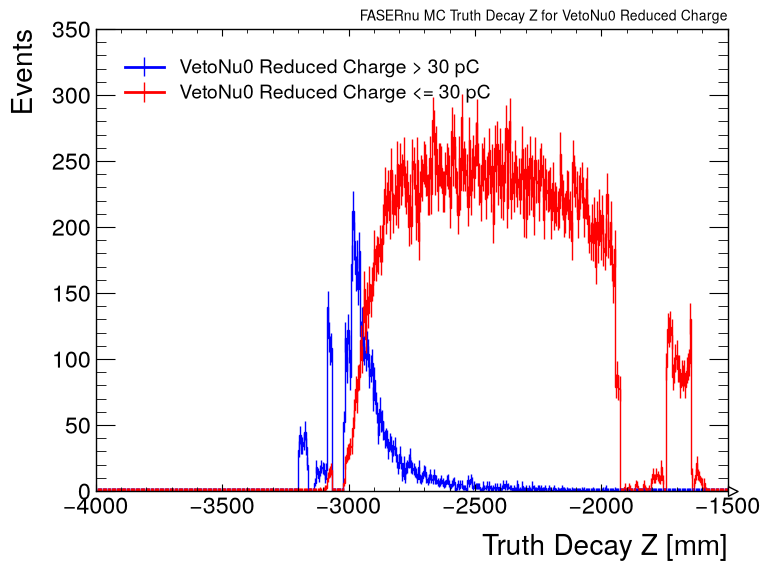

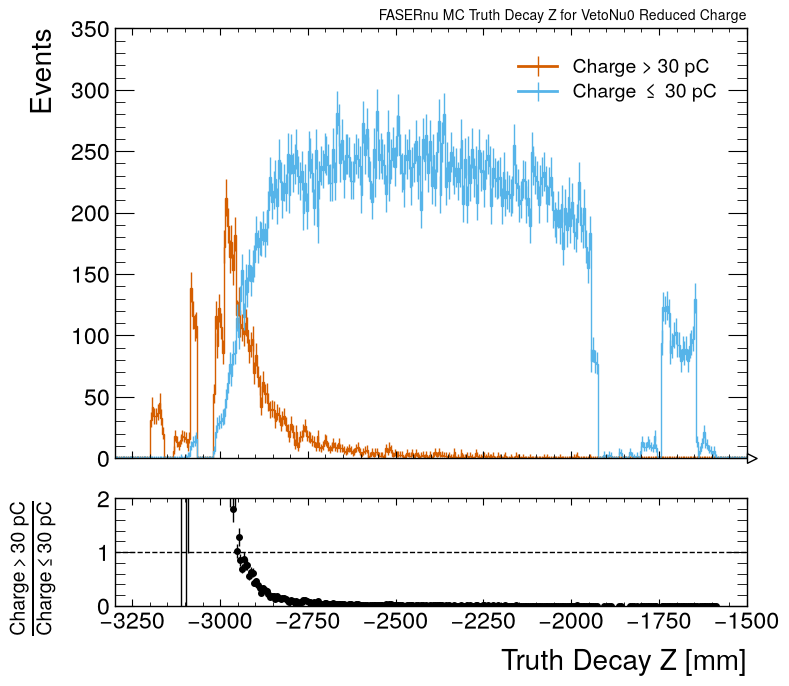

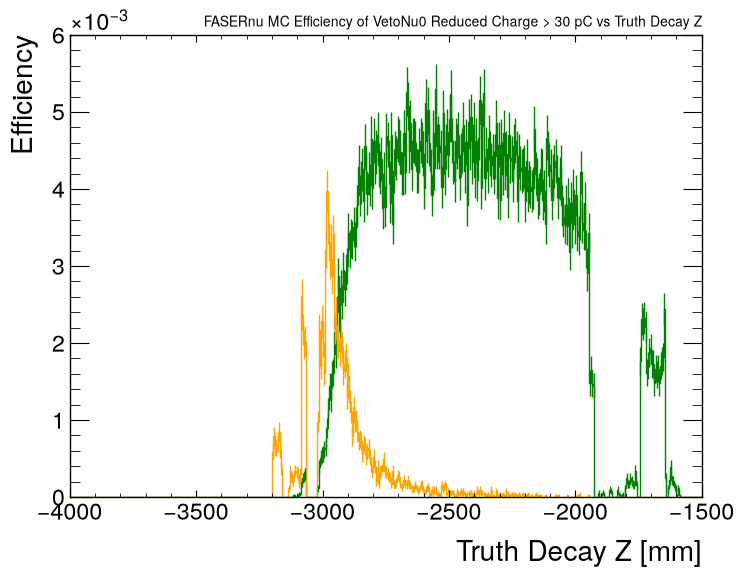

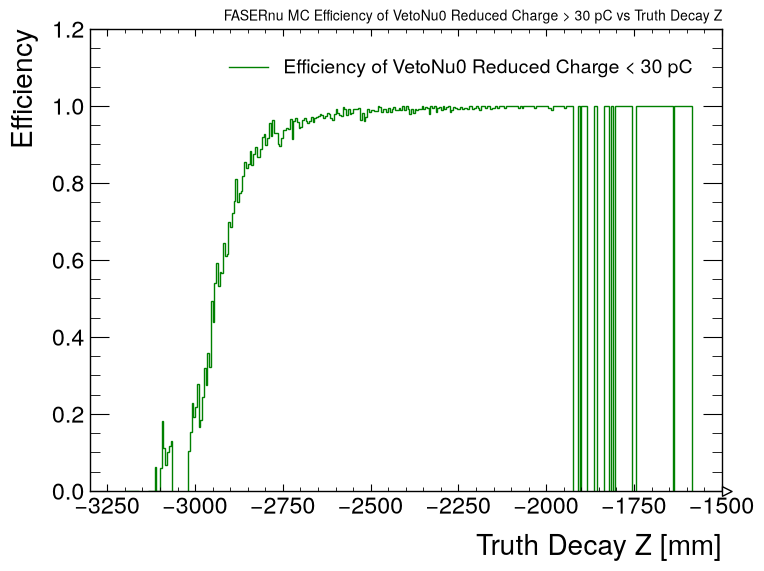

In [52]:
h_z_vs_q = hists_mc_noCaloNu["truth_dec_z_nu_vs_VetoNu0_reduced_charge"].to_boost()
h_z_high_q_slice = h_z_vs_q[:, bh.loc(30):]
# The slice folded charge>=30 entries into the overflow bin of axis 1.
# Zero it out so project() doesn't bring them back in.
view = h_z_high_q_slice.view(flow=True)
view[:, -1] = 0   # zero overflow bin of axis 1 (charge)
view[:, 0] = 0   # also zero underflow if relevant to your cut
h_z_high_q_slice_projz = h_z_high_q_slice.project(0)

h_z_vs_q = hists_mc_noCaloNu["truth_dec_z_nu_vs_VetoNu0_reduced_charge"].to_boost()
h_z_low_q_slice = h_z_vs_q[:, :bh.loc(30)]
# The slice folded charge>=30 entries into the overflow bin of axis 1.
# Zero it out so project() doesn't bring them back in.
view = h_z_low_q_slice.view(flow=True)
view[:, -1] = 0   # zero overflow bin of axis 1 (charge)
view[:, 0] = 0   # also zero underflow if relevant to your cut
h_z_low_q_slice_projz = h_z_low_q_slice.project(0)

fig, ax = plt.subplots(figsize=(8, 6))
mh.histplot(h_z_high_q_slice_projz, ax=ax, color="blue", label="VetoNu0 Reduced Charge > 30 pC")
mh.histplot(h_z_low_q_slice_projz, ax=ax, color="red", label="VetoNu0 Reduced Charge <= 30 pC")
ax.set_xlabel("Truth Decay Z [mm]")
ax.set_ylabel("Events")
ax.set_title("FASERnu MC Truth Decay Z for VetoNu0 Reduced Charge", fontsize=10, loc="right")
ax.legend()

# =========================
fig, ax_main, ax_comp = mh.comp.hists(
 h_z_high_q_slice_projz,
 h_z_low_q_slice_projz,
 comparison='ratio',
 xlabel='Truth Decay Z [mm]',
 ylabel='Events',
 h1_label='Charge > 30 pC',
 h2_label=r'Charge $\leq$ 30 pC'
)

ax_main.set_title("FASERnu MC Truth Decay Z for VetoNu0 Reduced Charge", fontsize=10, loc="right")
ax_main.set_xlim(-3300, -1500)
ax_comp.set_xlim(-3300, -1500)

ax_comp.set_ylabel(r"$\frac{\text{Charge} > \text{30 pC}}{\text{Charge} \leq \text{30 pC}}$")

# =========================
h_q_cut_eff_z = scale_histogram(h_z_low_q_slice_projz, 1/h_z_vs_q.sum(flow=True))

h_q_cut_ineff_z = scale_histogram(h_z_high_q_slice_projz, 1/h_z_vs_q.sum(flow=True))

print(f"Efficiency of VetoNu0 Reduced Charge < 30 pC: {h_q_cut_eff_z.sum(flow=True).value:.2%}")
print(f"Inefficiency of VetoNu0 Reduced Charge > 30 pC: {h_q_cut_ineff_z.sum(flow=True).value:.2%}")

fig, ax = plt.subplots(figsize=(8, 6))
mh.histplot(h_q_cut_eff_z, ax=ax, color="green", label="Efficiency of VetoNu0 Reduced Charge < 30 pC")
mh.histplot(h_q_cut_ineff_z, ax=ax, color="orange", label="Inefficiency of VetoNu0 Reduced Charge > 30 pC")
ax.set_xlabel("Truth Decay Z [mm]")
ax.set_ylabel("Efficiency")
ax.set_title("FASERnu MC Efficiency of VetoNu0 Reduced Charge > 30 pC vs Truth Decay Z", fontsize=10, loc="right")


# =========================
h_q_cut_eff_z = h_z_low_q_slice_projz / h_z_vs_q.project(0)
h_q_cut_ineff_z = h_z_high_q_slice_projz / h_z_vs_q.project(0)

print(f"Efficiency of VetoNu0 Reduced Charge < 30 pC: {h_q_cut_eff_z.sum(flow=True):.2%}")
print(f"Inefficiency of VetoNu0 Reduced Charge > 30 pC: {h_q_cut_ineff_z.sum(flow=True):.2%}")

fig, ax = plt.subplots(figsize=(8, 6))

rebin = 1
h_q_cut_eff_z_FaserNu = h_q_cut_eff_z[bh.rebin(rebin)]

mh.histplot(h_q_cut_eff_z[bh.rebin(rebin)], ax=ax, color="green", label="Efficiency of VetoNu0 Reduced Charge < 30 pC")
# mh.histplot(h_q_cut_ineff_z[bh.rebin(rebin)], ax=ax, color="orange", label="Inefficiency of VetoNu0 Reduced Charge > 30 pC")
ax.set_xlabel("Truth Decay Z [mm]")
ax.set_ylabel("Efficiency")
# ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.legend()
ax.set_title("FASERnu MC Efficiency of VetoNu0 Reduced Charge > 30 pC vs Truth Decay Z", fontsize=10, loc="right")
ax.set_xlim(-3300, -1500)

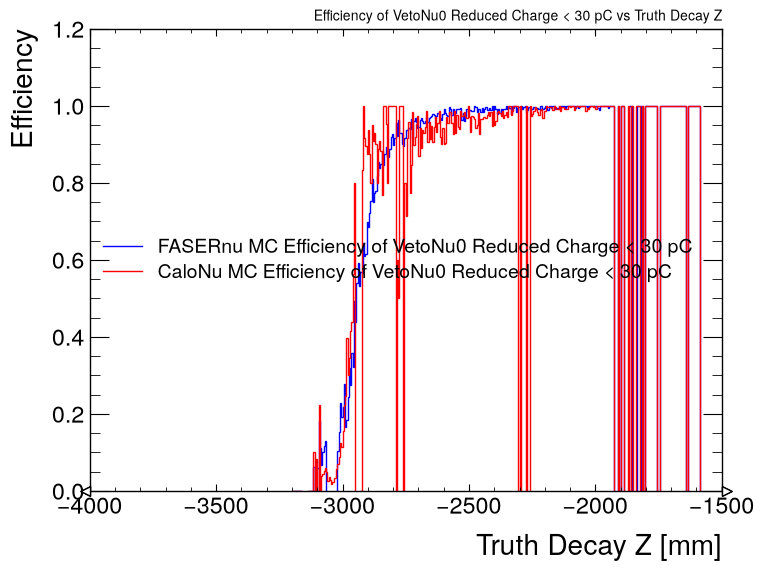

In [53]:
fig, ax = plt.subplots(figsize=(8, 6))
mh.histplot(h_q_cut_eff_z_FaserNu, ax=ax, color="blue", label="FASERnu MC Efficiency of VetoNu0 Reduced Charge < 30 pC")
mh.histplot(h_q_cut_eff_z_CaloNu, ax=ax, color="red", label="CaloNu MC Efficiency of VetoNu0 Reduced Charge < 30 pC")
ax.set_xlabel("Truth Decay Z [mm]")
ax.set_ylabel("Efficiency")
ax.set_title("Efficiency of VetoNu0 Reduced Charge < 30 pC vs Truth Decay Z", fontsize=10, loc="right")
ax.legend()


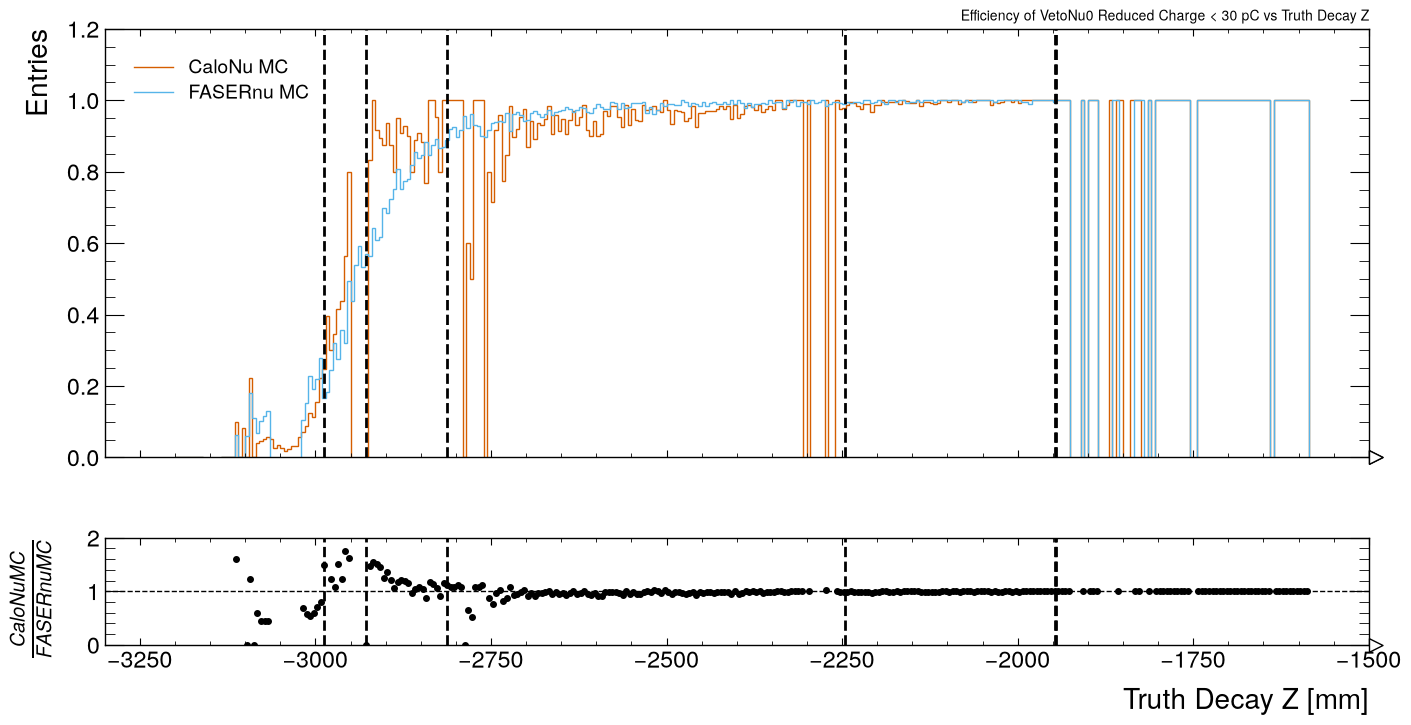

In [54]:
front = [-2987.39, -1945.67]
middle = [-2965.18, -2246.18]
back = [-2246.18, -1946.18]

pmt = [-2928.0, -2812.0]

fig, axes = mh.subplots(nrows=2, hspace=0.3, figsize=(16, 8))

fig, ax_main, ax_comparison = mh.comp.hists(
    h_q_cut_eff_z_CaloNu,
    h_q_cut_eff_z_FaserNu,
    fig=fig,
    ax_main=axes[0],
    ax_comparison=axes[1],
    xlabel="Truth Decay Z [mm]",
    ylabel="Entries",
    h1_label=r"CaloNu MC",
    h2_label=r"FASERnu MC",
    comparison="ratio",
    
)


xlims = (-3300, -1500)
ax_main.set_xlim(xlims)
ax_main.set_title("Efficiency of VetoNu0 Reduced Charge < 30 pC vs Truth Decay Z", fontsize=10, loc="right")
ax_comparison.set_xlim(xlims)

ax_main.axvline(pmt[0], color="black", linestyle="--", label="PMT Region")
ax_main.axvline(pmt[1], color="black", linestyle="--")
ax_main.axvline(front[0], color="black", linestyle="--", label="Front Region")
ax_main.axvline(front[1], color="black", linestyle="--")
ax_main.axvline(back[0], color="black", linestyle="--", label="Back Region")
ax_main.axvline(back[1], color="black", linestyle="--")
ax_comparison.axvline(pmt[0], color="black", linestyle="--", label="PMT Region")
ax_comparison.axvline(pmt[1], color="black", linestyle="--")
ax_comparison.axvline(front[0], color="black", linestyle="--", label="Front Region")
ax_comparison.axvline(front[1], color="black", linestyle="--")
ax_comparison.axvline(back[0], color="black", linestyle="--", label="Back Region")
ax_comparison.axvline(back[1], color="black", linestyle="--")